In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_differences(file1, file2, output_path=None):
    arr1 = np.load(file1)
    arr2 = np.load(file2)
    t = arr1.shape[0]
    arr1 = arr1.reshape(t, -1)
    arr2 = arr2.reshape(t, -1)
    
    # Calculate differences
    diff = arr1 - arr2
    
    # For better visualization, limit extremely large values
    vmax = np.percentile(np.abs(diff), 95)  # Use 95th percentile for color scaling
    vmin = -vmax
    
    # Create a more detailed heatmap of differences
    plt.figure(figsize=(14, 10))
    
    # Use seaborn's heatmap which has better defaults for this type of visualization
    ax = sns.heatmap(
        diff, 
        cmap='coolwarm', 
        vmin=vmin, 
        vmax=vmax,
        center=0,
        cbar_kws={'label': 'Difference'},
        xticklabels=20,  # Show every 20th feature label
        yticklabels=50   # Show every 50th timestep label
    )
    
    plt.title(f'Differences between {os.path.basename(file1)} and {os.path.basename(file2)}', fontsize=14)
    plt.xlabel('Features', fontsize=12)
    plt.ylabel('Timesteps', fontsize=12)
    
    # Add annotations about statistics
    abs_diff = np.abs(diff)
    max_diff = np.max(abs_diff)
    mean_diff = np.mean(abs_diff)
    max_idx = np.unravel_index(np.argmax(abs_diff), abs_diff.shape)
    
    stats_text = f"Max diff: {max_diff:.4f} at {max_idx}\nMean diff: {mean_diff:.4f}"
    plt.figtext(0.02, 0.02, stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
    
    # Mark the location of maximum difference
    plt.plot(max_idx[1], max_idx[0], 'rx', markersize=8)
    
    plt.tight_layout()
    
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()
        
    # Also create a simplified view showing just the magnitude of differences
    plt.figure(figsize=(14, 6))
    
    # Plot mean difference per feature
    feature_means = np.mean(abs_diff, axis=0)
    plt.subplot(1, 2, 1)
    plt.bar(range(len(feature_means)), feature_means)
    plt.title('Mean Diff by Feature')
    plt.xlabel('Feature Index')
    plt.ylabel('Mean Absolute Difference')
    
    # Plot mean difference per timestep
    timestep_means = np.mean(abs_diff, axis=1)
    plt.subplot(1, 2, 2)
    plt.plot(timestep_means)
    plt.title('Difference over Time')
    plt.xlabel('Timestep')
    plt.ylabel('Mean Absolute Difference')
    
    plt.tight_layout()
    
    if output_path:
        summary_path = output_path.replace('.png', '_summary.png')
        plt.savefig(summary_path, dpi=150, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

In [ ]:
import os
import sys
import numpy as np
from pathlib import Path

def compare_npy_files(file1, file2, rtol=1e-05, atol=1e-08):
    arr1 = np.load(file1)
    arr2 = np.load(file2)
    equal = np.allclose(arr1, arr2, rtol=rtol, atol=atol)
    return equal

def cosine_similarity(vec1, vec2):
    norm1 = np.linalg.norm(vec1)
    norm2 = np.linalg.norm(vec2)
    if norm1 == 0 or norm2 == 0:
        return np.nan
    return np.dot(vec1, vec2) / (norm1 * norm2)

def compare_directories(dir1, dir2):
    discrepancies = []
    for root, _, files in os.walk(dir1):
        for file in files:
            if file.endswith('.npy'):
                rel_path = os.path.relpath(root, dir1)
                file1 = os.path.join(root, file)
                file2 = os.path.join(dir2, rel_path, f"M_{file}")
                if not os.path.exists(file2):
                    discrepancies.append(f"Missing file: {file2}")
                    continue

                # Load arrays once here to compute cosine similarity if needed.
                arr1 = np.load(file1)
                arr2 = np.load(file2)
                if not np.allclose(arr1, arr2, rtol=1e-05, atol=1e-08):
                    # Flatten arrays for cosine similarity calculation.
                    vec1 = arr1.ravel()
                    vec2 = arr2.ravel()
                    cos_sim = cosine_similarity(vec1, vec2)
                    discrepancies.append(f"Data differs: {Path(file1).stem} vs {Path(file2).stem} | {arr1.shape} vs {arr2.shape} | Cosine Similarity: {cos_sim:.4f}")
                    plot_save_path = os.path.join("kit_pose_data_diff", rel_path)
                    os.makedirs(plot_save_path, exist_ok=True)
                    #plot_differences(file1, file2, output_path=os.path.join(plot_save_path, f'diff_{file}'.replace('.npy', '.png')))
    return discrepancies

KeyboardInterrupt: 

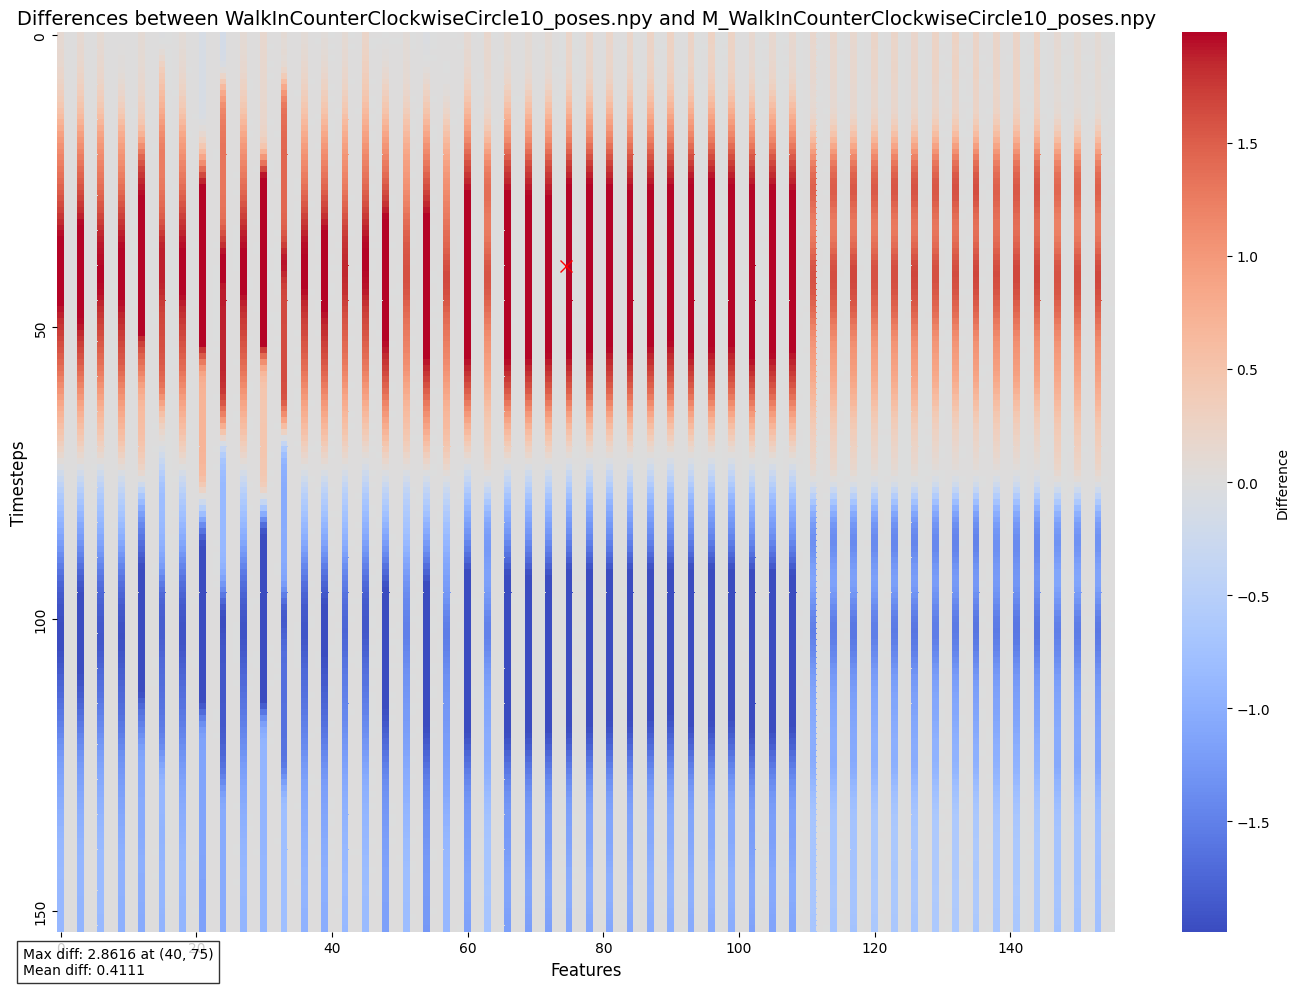

In [14]:

directory1, directory2 = "kit_pose_data/KIT/KIT", "/lsdf/users/dschneider-kf3609/workspace/HumanML3D/joints_comp/KIT"
diffs = compare_directories(directory1, directory2)
if diffs:
    print("Differences found:")
    for d in diffs:
        print(d)
else:
    print("No differences found. The directories are identical (within tolerance).")